In [ ]:
# Standard library imports
import os
import warnings

# Data science and statistics imports
import numpy as np
import pandas as pd

# Single-cell analysis imports
import scanpy as sc
import anndata as ad

# Ignore the warning messages
warnings.filterwarnings("ignore")


[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: pip install --upgrade pip


## Pseudotime and Trajectory Inference in LVAE-Generated Data

### **Objective**
The purpose of this notebook is to evaluate whether the **synthetic single-cell RNA-seq data** generated by the **LVAE model** capture **continuous biological transitions** and **cellular trajectories** comparable to real data.  
To do so, we apply **trajectory inference** methods to visualize and analyze the latent structure of the dataset.


### **Workflow Summary**

1. **Dimensionality Reduction**  
   Principal Component Analysis (PCA), t-SNE, and diffusion maps are used to project high-dimensional gene expression data into lower-dimensional spaces, revealing the main axes of transcriptional variation.

2. **Diffusion Pseudotime (DPT)**  
   Diffusion pseudotime analysis infers a **temporal ordering of cells** along potential differentiation trajectories.  
   Results are visualized both in diffusion map and t-SNE embeddings, highlighting dynamic cellular progression.

3. **Pseudotime Distribution per Cell Type**  
   Violin plots display the **distribution of pseudotime values** across different cell types, allowing comparison of early and late populations within the inferred trajectory.

4. **Global Connectivity with PAGA**  
   The **Partition-based Graph Abstraction (PAGA)** algorithm summarizes the overall connectivity between cell populations, reconstructing potential lineage relationships and transitions between cell states.


### **Interpretation**
This analysis provides a global view of how well the **LVAE-generated data** reproduce realistic **biological continuity** and **differentiation patterns**.  
If the pseudotime and PAGA results resemble known cellular hierarchies, this supports the model’s **biological validity** and its potential for downstream **trajectory and developmental modeling** in single-cell research.


### **Summary**

| Step | Operation | Output |
|------|------------|---------|
| 1 | Build k-NN graph | Cell similarity network |
| 2 | Compute diffusion map | Continuous manifold |
| 3 | Define root cell | Starting point |
| 4 | Calculate DPT | Pseudotime ordering |
| 5 | Visualize | Trajectory structure |

In [ ]:
def load_and_merge(folder: str, filetype: str = ".h5ad") -> ad.AnnData:
    """
    Load and merge multiple AnnData (.h5ad) files from a given folder.

    This function scans a directory for all files with the specified extension,
    loads each one as an AnnData object, and concatenates them into a single
    AnnData object.

    Parameters
    ----------
    folder : str
        Path to the folder containing the files to load.
    filetype : str, optional
        File extension to look for (default: '.h5ad').

    Returns
    -------
    AnnData
        A single merged AnnData object containing all loaded datasets.
    """
    adatas = []
    fnames = sorted([f for f in os.listdir(folder) if f.endswith(filetype)])

    for fname in fnames:
        path = os.path.join(folder, fname)
        print(f"Loading: {path}")
        adata = sc.read(path)
        adatas.append(adata)

    adata_merged = ad.concat(adatas, join="outer", fill_value=0)

    return adata_merged

In [3]:
###################################################################################################333

### ADATA LVAE

In [4]:
adata_lvae = load_and_merge("/home/app/ACTIVA/mus musculus/datos_mus_musculus")
adata_lvae.obs["cell_origin"] = "synthetic"

Loading: /home/app/ACTIVA/mus musculus/datos_mus_musculus/Acinar cells_cholesky.h5ad
Loading: /home/app/ACTIVA/mus musculus/datos_mus_musculus/B cells_cholesky.h5ad
Loading: /home/app/ACTIVA/mus musculus/datos_mus_musculus/Dendritic cells_cholesky.h5ad
Loading: /home/app/ACTIVA/mus musculus/datos_mus_musculus/Ductal cells_cholesky.h5ad
Loading: /home/app/ACTIVA/mus musculus/datos_mus_musculus/Early Metaplastic cells_cholesky.h5ad
Loading: /home/app/ACTIVA/mus musculus/datos_mus_musculus/Endocrine cells_cholesky.h5ad
Loading: /home/app/ACTIVA/mus musculus/datos_mus_musculus/Fibroblast_cholesky.h5ad
Loading: /home/app/ACTIVA/mus musculus/datos_mus_musculus/Macrophages_cholesky.h5ad
Loading: /home/app/ACTIVA/mus musculus/datos_mus_musculus/Metaplastic cells_cholesky.h5ad
Loading: /home/app/ACTIVA/mus musculus/datos_mus_musculus/Neutrophils_cholesky.h5ad
Loading: /home/app/ACTIVA/mus musculus/datos_mus_musculus/Pericytes_cholesky.h5ad
Loading: /home/app/ACTIVA/mus musculus/datos_mus_muscul

In [ ]:
# Clean cell type labels in LVAE AnnData object
# Remove the suffix " Cholesky" from all cell type names to standardize nomenclature.
adata_lvae.obs["cell_type"] = (
    adata_lvae.obs["cell_type"]
    .astype(str)
    .str.replace(" Cholesky", "", regex=False)
)

# Convert back to categorical to preserve a clean, ordered representation of cell types.
adata_lvae.obs["cell_type"] = pd.Categorical(adata_lvae.obs["cell_type"])

In [6]:
###################################################################################################333

In [7]:
# PCA and UMAP embedding of the LVAE-generated dataset
# Ensure the expression matrix is a NumPy array (not sparse)
adata_lvae.X = np.asarray(adata_lvae.X)

# Perform Principal Component Analysis (PCA)
# to reduce dimensionality and capture the main sources of variation.
sc.tl.pca(adata_lvae, svd_solver="arpack")

# Build the neighborhood graph using the first 34 principal components
sc.pp.neighbors(adata_lvae, n_pcs=34)

# Compute the UMAP embedding for visualization in two dimensions
sc.tl.umap(adata_lvae)


2025-10-13 18:12:48.812907: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-13 18:12:48.821303: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1760379168.835006   13008 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1760379168.839111   13008 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1760379168.849890   13008 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1760379168.849914   13008 computation_placer.cc:177] computation placer already registered. Please che

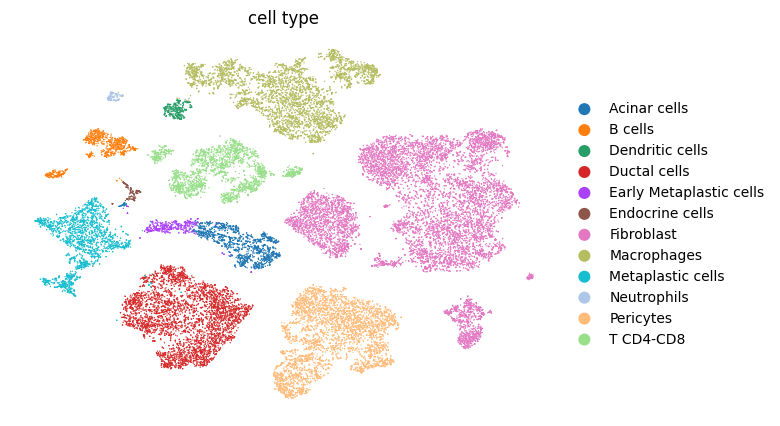

In [8]:
# Compute t-SNE and Diffusion Map embeddings for LVAE data

# Compute t-SNE using the PCA representation (X_pca)
sc.tl.tsne(adata_lvae, use_rep="X_pca", perplexity=40)

# Compute a diffusion map embedding: diffusion maps are useful for capturing continuous trajectories in the data (e.g., cell differentiation).
sc.tl.diffmap(adata_lvae)

# Visualize the t-SNE embedding colored by cell type
sc.pl.scatter(adata_lvae, basis="tsne", color="cell_type", frameon=False)


In [9]:
# Identify the root cell as the one with the minimum value along diffusion component 5
#(corresponding to the "starting" point in a trajectory)
root_ixs = adata_lvae.obsm["X_diffmap"][:, 5].argmin()

# Store the root cell index in AnnData for downstream trajectory analyses
adata_lvae.uns["iroot"] = root_ixs

In [10]:
# Compute diffusion pseudotime (DPT), which orders cells along a continuous trajectory
# based on the diffusion map representation.
sc.tl.dpt(adata_lvae)

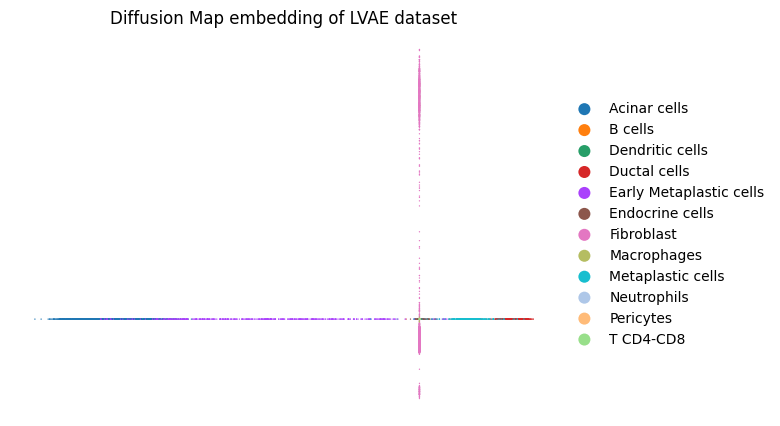

In [11]:
# Visualize cells in Diffusion Map space (components 5 vs 6), colored by cell type
sc.pl.scatter(
    adata_lvae,
    basis="diffmap",
    color=["cell_type"],
    components=[5, 6],
    frameon=False,
    title="Diffusion Map embedding of LVAE dataset"
)

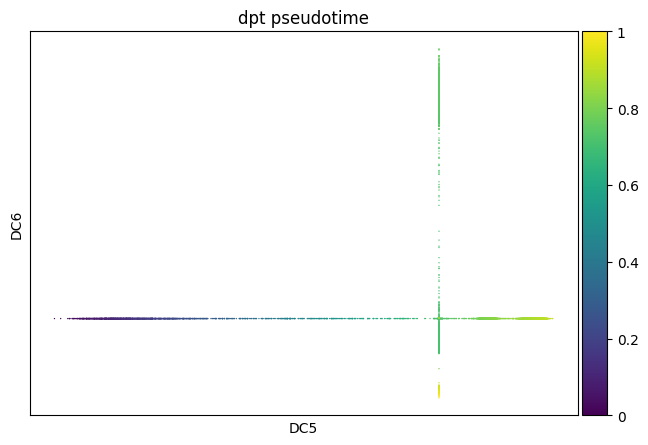

In [12]:
# Visualize the inferred pseudotime along the diffusion map embedding.
sc.pl.scatter(
    adata_lvae,
    color="dpt_pseudotime",
    basis="diffmap",
    components=[5, 6]
)


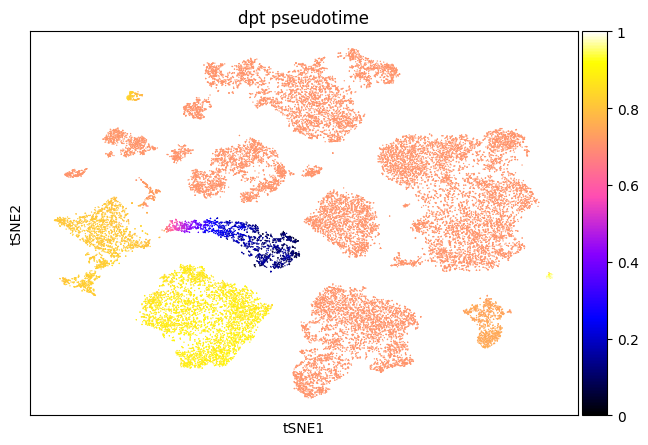

In [13]:
# Visualize pseudotime on the t-SNE embedding

# Plot the t-SNE projection of the LVAE data,
# coloring each cell by its diffusion pseudotime value.
# This representation allows visualizing the inferred cellular progression
# (e.g., from progenitor to differentiated states) in a 2D layout.

sc.pl.scatter(
    adata_lvae,
    basis="tsne",
    color=["dpt_pseudotime"],
    color_map="gnuplot2",
    save="pseudotime_umap"
)


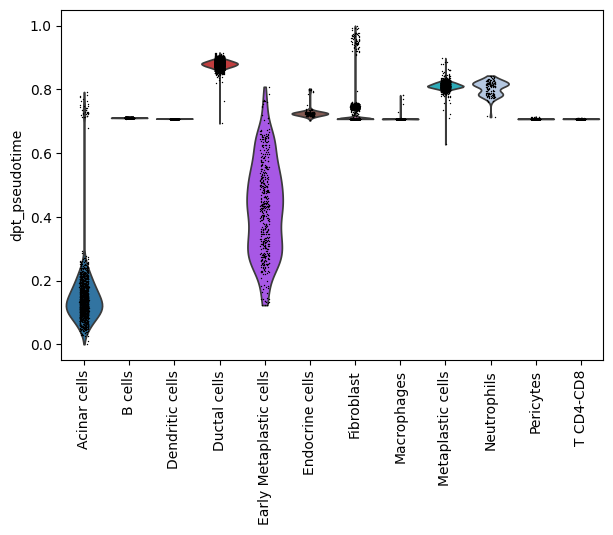

In [14]:
# Visualize pseudotime distribution per cell type

# Generate a violin plot of diffusion pseudotime (DPT) values grouped by cell type.
# This representation shows how each cell population is positioned along
# the inferred trajectory — highlighting potential ordering or transitions
# between different cell types.
sc.pl.violin(
    adata_lvae,
    keys=["dpt_pseudotime"],
    groupby="cell_type",
    rotation=90,
    save="pseudotime"
)


In [15]:
###################################################################################################333

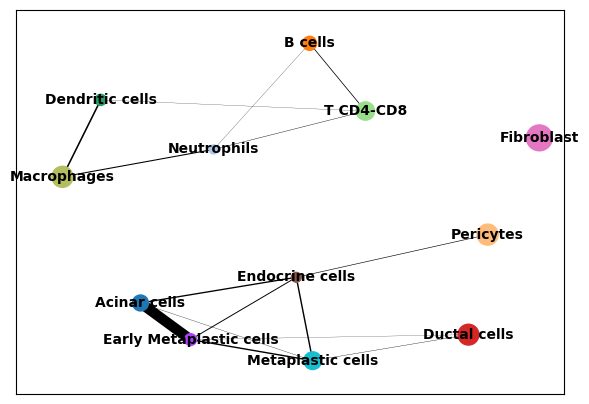

In [16]:
# Compute PAGA graph to visualize cell-type connectivity ---
# Rank cells by pseudotime to establish an order along the inferred trajectory
adata_lvae.obs["dpt_order_indices"] = adata_lvae.obs["dpt_pseudotime"].rank().astype(int)

# Recompute the neighborhood graph using PCA representation (if not already done)
sc.pp.neighbors(adata_lvae, n_neighbors=15, use_rep="X_pca")

# Run PAGA (Partition-based Graph Abstraction), which builds a connectivity graph
# between cell-type clusters, representing potential developmental transitions.
sc.tl.paga(adata_lvae, groups="cell_type")

# Visualize the PAGA connectivity graph colored by cell type.
# The size of nodes reflects cluster sizes, and edge thickness represents
# connection strength (probability of transition).
sc.pl.paga(adata_lvae, color=["cell_type"], save="paga_mus")